# Top-1,000 follower reach: log–log population scaling

## tl;dr

This model asks how mapped top-1,000 **follower totals** scale with FUA
population among places with positive output.

- The population exponent is **1.52**
  with HC3 95% CI **1.20–1.84**
  (`β = 1` test, **p = 0.0015**).
  Follower output also scales superlinearly in this catalogue.
- The model explains **50.6%** of log-scale
  variation, but leave-one-out RMSE is **1.52**
  log points, roughly a **4.6×** multiplicative error.
- The slope is reasonably stable: Huber regression gives
  **1.54** and leave-one-city-out
  slopes range from **1.47** to
  **1.60**.
- **Crawley** is the largest positive residual at
  **36.4×** its fitted median, but it is a
  single-band result, demonstrating the superstar problem.
- The regression uses **61 positive-output FUAs** and necessarily excludes
  **22 zero-output FUAs**.

Taken together, log–log regression is useful for **audience impact and the
shape of scaling**, but it is weaker as the primary city-scene model because it
drops zeros and follower totals can be dominated by one act.

## 01. Context and methods

The response is the summed Spotify follower count of mapped bands in each FUA.
The fitted model is:

$$
\log(F_i) = a + \beta\log(P_i) + \epsilon_i.
$$

Ordinary least squares estimates the line; HC3 covariance supplies
heteroskedasticity-robust uncertainty. The null `β = 1` is proportional
scaling. Exponentiating a residual gives the observed follower total relative
to the fitted conditional median. Huber regression and leave-one-city-out
slopes are retained as influence checks.

### Assumptions

- Only FUAs with positive mapped follower output can enter an ordinary log–log
  regression; no arbitrary `+1` pseudocount is used.
- Followers are summed artist-level counts with unknown audience overlap.
- Residuals measure global Spotify reach associated with bands assigned to an
  FUA, not local listenership or scene depth.
- Superstar concentration, catalogue selection, mapping coverage and the
  current-versus-historical population mismatch remain material limitations.

## 02. Data

In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "data/processed/popularity_first_top1000_20260718T204522Z_bands.csv").exists()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Could not locate the uk-music-cities repository root")

import sys
SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from python_uk_bands.output_share import build_output_share_metrics

SNAPSHOT_ID = "20260718T204522Z"
TOP_N = 1000
BANDS_PATH = ROOT / "data/processed/popularity_first_top1000_20260718T204522Z_bands.csv"
MAPPING_AUDIT_PATH = ROOT / "data/interim/popularity_first_top1000_20260718T204522Z_fua_mapping_audit.csv"
POPULATION_PATH = ROOT / "data/processed/uk_fua_population_2021_20260718T201304Z.csv"
ARTIFACT_DIR = ROOT / "artifacts/experiments/top1000_scaling_models/20260718T204522Z"

bands = pd.read_csv(BANDS_PATH, keep_default_na=False)
mapping_audit = pd.read_csv(MAPPING_AUDIT_PATH, keep_default_na=False)
population = pd.read_csv(POPULATION_PATH, keep_default_na=False)

shares, coverage = build_output_share_metrics(
    bands,
    mapping_audit,
    population,
    included_tiers={"strict", "reviewed_extended"},
)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

assert len(bands) == bands["returned_spotify_id"].nunique() == TOP_N
assert len(mapping_audit) == TOP_N
assert len(shares) == coverage["population_fuas"] == 83
assert coverage["mapped_bands"] == int(shares["band_count"].sum()) == 660
assert coverage["zero_band_fuas"] == int(shares["band_count"].eq(0).sum()) == 22

coverage_table = pd.DataFrame(
    [
        {"Measure": "FUAs in population universe", "Value": coverage["population_fuas"]},
        {"Measure": "Positive-output FUAs", "Value": coverage["mapped_fuas"]},
        {"Measure": "Zero-output FUAs excluded from log fit", "Value": coverage["zero_band_fuas"]},
        {"Measure": "Mapped follower share", "Value": coverage["mapped_follower_share"]},
        {"Measure": "Mapped bands", "Value": coverage["mapped_bands"]},
    ]
)
display(
    coverage_table.style.hide(axis="index").format(
        {"Value": lambda value: f"{value:.1%}" if isinstance(value, float) and value < 1 else f"{value:g}"}
    )
)


Measure,Value
FUAs in population universe,83
Positive-output FUAs,61
Zero-output FUAs excluded from log fit,22
Mapped follower share,92.4%
Mapped bands,660


The fit covers every FUA with at least one mapped band but cannot represent the 22 zero-output places. This is an explicit selection condition, not a plotting choice.

## 03. Results

### 03.01 Fit the log–log model

In [2]:
from python_uk_bands.scaling_models import (
    fit_loglog_follower_scaling,
    plot_loglog_follower_fit,
    plot_loglog_follower_residuals,
)

model_results, model_summary = fit_loglog_follower_scaling(shares)
RESULTS_PATH = ARTIFACT_DIR / "loglog_follower_fua_results.csv"
SUMMARY_PATH = ARTIFACT_DIR / "loglog_follower_model_summary.json"
model_results.to_csv(RESULTS_PATH, index=False)
with SUMMARY_PATH.open("w", encoding="utf-8") as handle:
    json.dump(model_summary, handle, indent=2, sort_keys=True)

coefficient_table = pd.DataFrame(
    [
        {
            "Population exponent β": model_summary["population_exponent_beta"],
            "HC3 95% CI low": model_summary["beta_ci_low_hc3"],
            "HC3 95% CI high": model_summary["beta_ci_high_hc3"],
            "p-value for β = 1": model_summary["beta_equals_one_p_value_hc3"],
            "Huber β": model_summary["huber_population_exponent_beta"],
        }
    ]
)
display(coefficient_table.style.hide(axis="index").format(precision=3))
display(Markdown(f"Saved `{RESULTS_PATH.relative_to(ROOT)}` and `{SUMMARY_PATH.relative_to(ROOT)}`."))


Population exponent β,HC3 95% CI low,HC3 95% CI high,p-value for β = 1,Huber β
1.522,1.200,1.844,0.001,1.539


Saved `artifacts/experiments/top1000_scaling_models/20260718T204522Z/loglog_follower_fua_results.csv` and `artifacts/experiments/top1000_scaling_models/20260718T204522Z/loglog_follower_model_summary.json`.

### 03.02 Compare parity with the fitted scaling relationship

/Users/dpradilla/dev/uk-music-cities/src/python_uk_bands/scaling_models.py:598: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


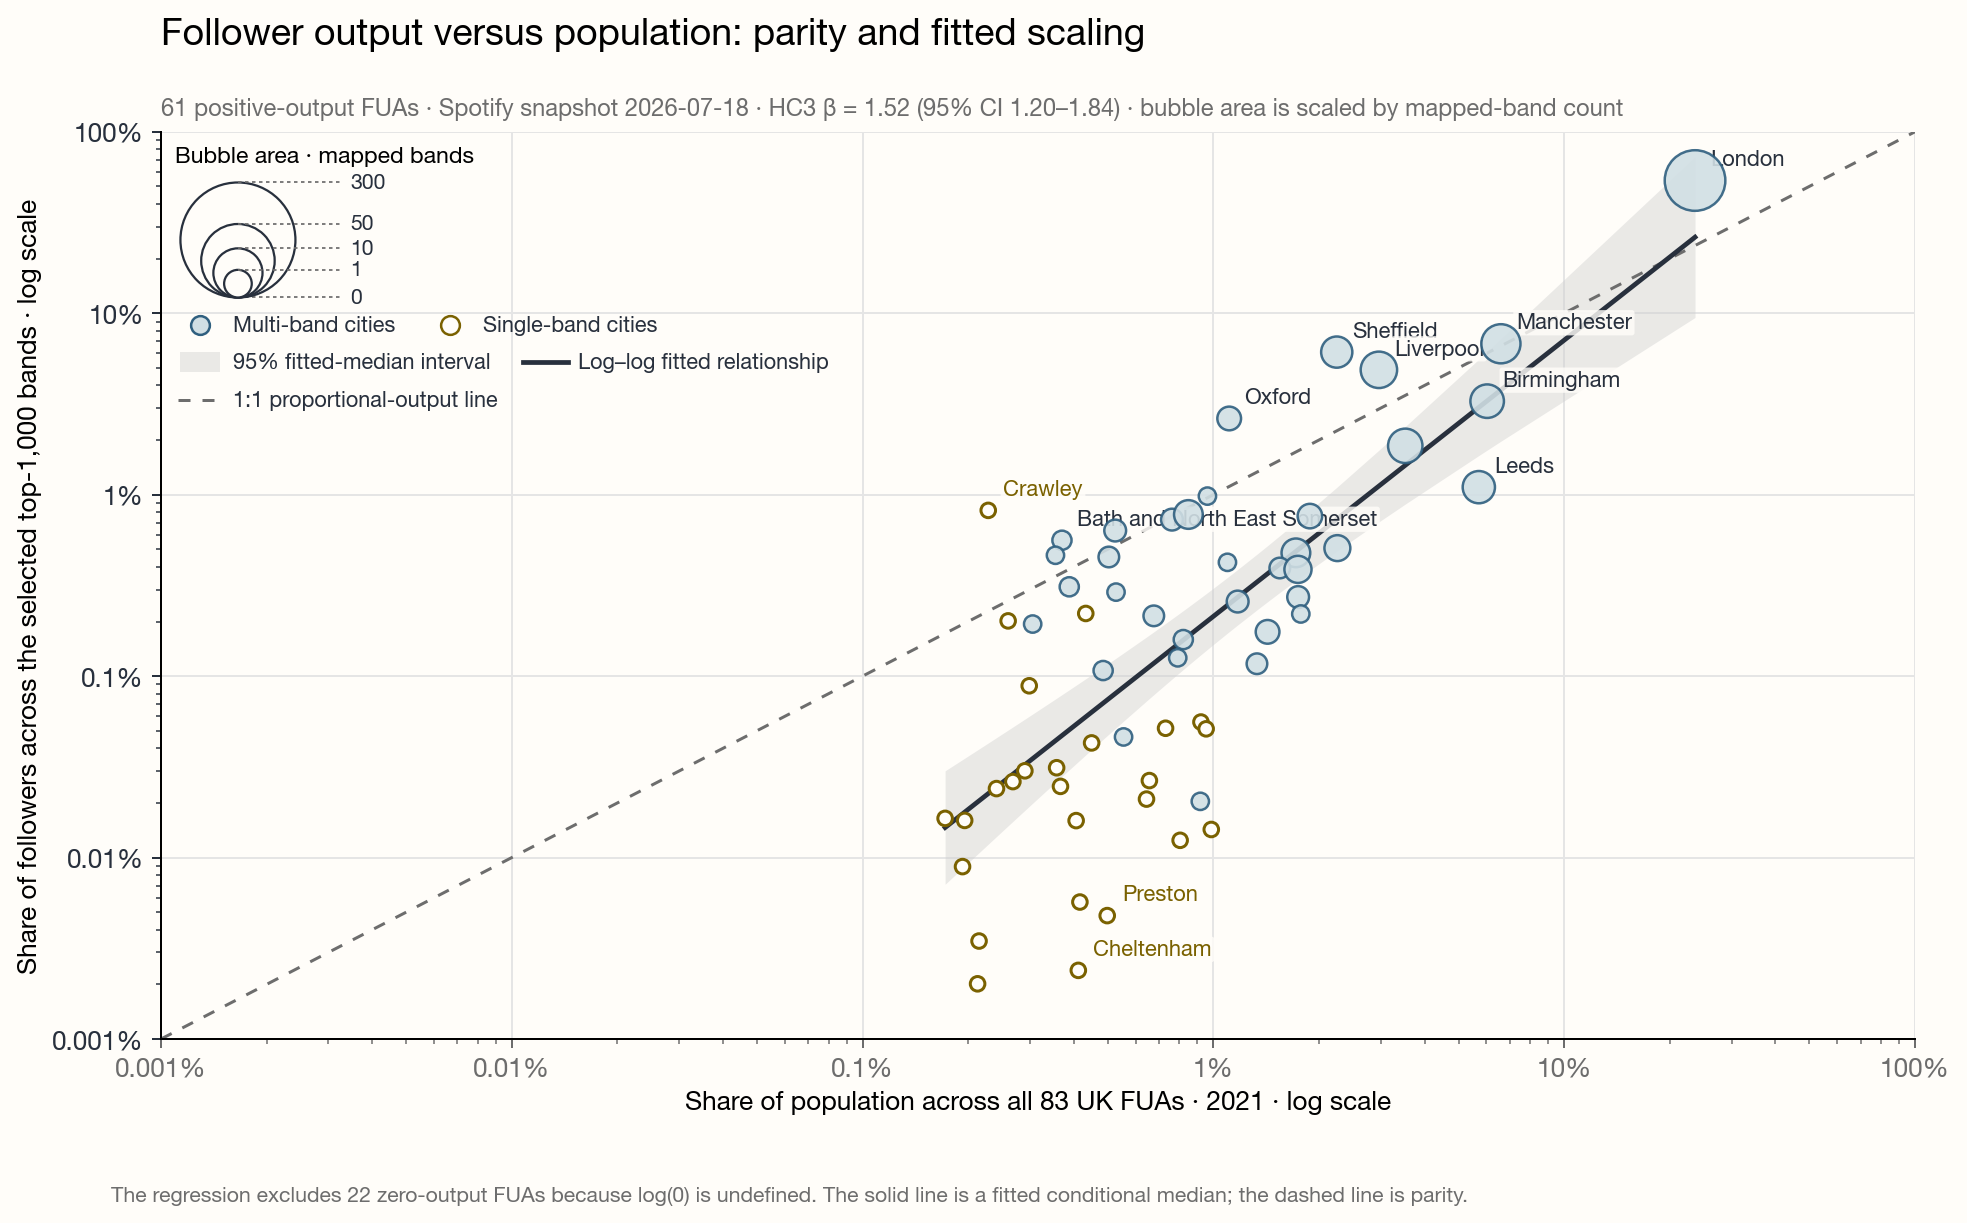

Exported to `artifacts/experiments/top1000_scaling_models/20260718T204522Z/chart_01_loglog_follower_fit.png`.

In [3]:
fit_chart_path = plot_loglog_follower_fit(
    model_results,
    model_summary,
    snapshot_date="2026-07-18",
    output_dir=ARTIFACT_DIR,
)
display(Image(filename=str(fit_chart_path)))
display(Markdown(f"Exported to `{fit_chart_path.relative_to(ROOT)}`."))


The dashed line retains the original proportional-output benchmark. The solid line is the empirically fitted relationship. Because `β > 1`, the gap between those expectations changes with city size. Bubble area is scaled by mapped-band count.

### 03.03 Which cities depart most from the fitted line?

/Users/dpradilla/dev/uk-music-cities/src/python_uk_bands/scaling_models.py:598: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


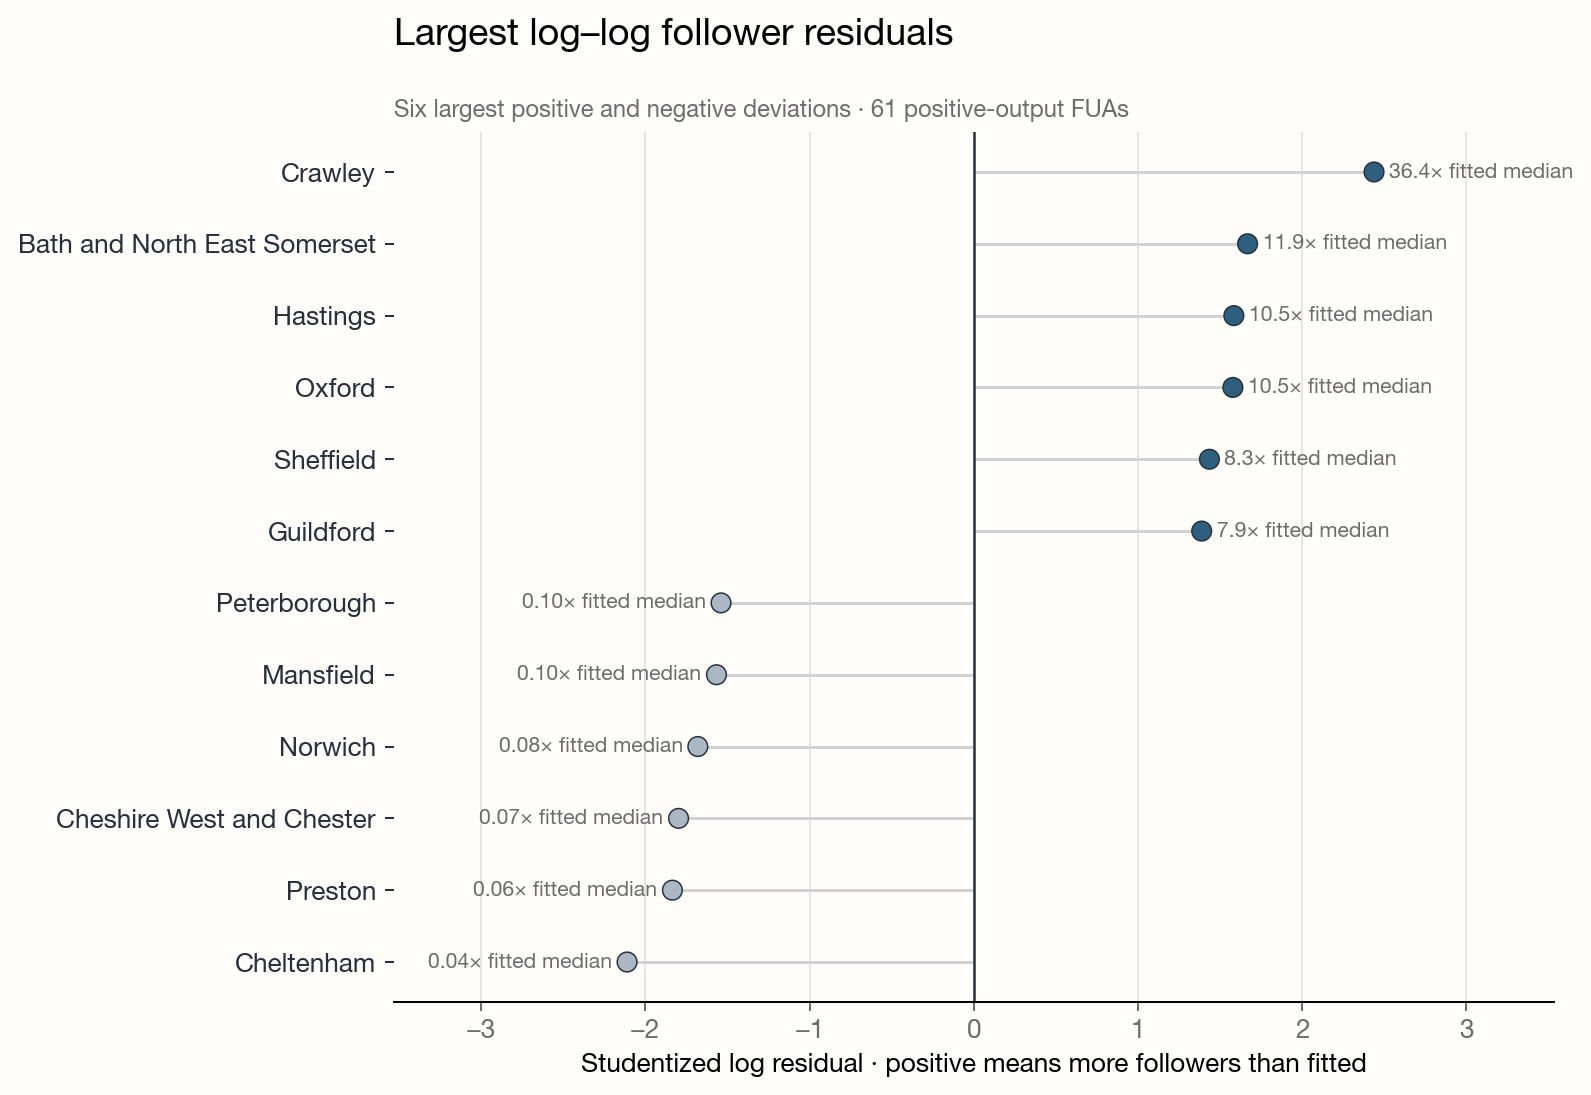

Exported to `artifacts/experiments/top1000_scaling_models/20260718T204522Z/chart_02_loglog_follower_residuals.png`.

In [4]:
residual_chart_path = plot_loglog_follower_residuals(
    model_results,
    output_dir=ARTIFACT_DIR,
)
display(Image(filename=str(residual_chart_path)))
display(Markdown(f"Exported to `{residual_chart_path.relative_to(ROOT)}`."))


In [5]:
notable_cities = [
    "London", "Manchester", "Liverpool", "Sheffield",
    "Birmingham", "Leeds", "Oxford", "Crawley",
]
notable = (
    model_results.loc[
        model_results["study_city_label"].isin(notable_cities),
        [
            "study_city_label", "band_count", "followers_total",
            "expected_follower_median", "observed_to_expected_median",
            "studentized_log_residual", "largest_band_follower_share",
        ],
    ]
    .sort_values("studentized_log_residual", ascending=False)
    .rename(
        columns={
            "study_city_label": "FUA",
            "band_count": "Mapped bands",
            "followers_total": "Observed followers",
            "expected_follower_median": "Fitted median",
            "observed_to_expected_median": "Observed / fitted",
            "studentized_log_residual": "Studentized residual",
            "largest_band_follower_share": "Largest-band share",
        }
    )
)
display(
    notable.style.hide(axis="index").format(
        {
            "Observed followers": "{:,.0f}",
            "Fitted median": "{:,.0f}",
            "Observed / fitted": "{:.2f}×",
            "Studentized residual": "{:+.2f}",
            "Largest-band share": "{:.1%}",
        }
    )
)


FUA,Mapped bands,Observed followers,Fitted median,Observed / fitted,Studentized residual,Largest-band share
Crawley,1,"7,492,117","205,912",36.39×,+2.44,100.0%
Oxford,7,"24,050,638","2,286,099",10.52×,+1.58,69.1%
Sheffield,21,"55,840,411","6,695,387",8.34×,+1.43,62.7%
Liverpool,39,"44,594,392","10,201,580",4.37×,+1.00,72.6%
London,299,"492,726,154","240,089,500",2.05×,+0.54,13.1%
Manchester,52,"62,068,335","34,517,475",1.80×,+0.41,22.5%
Birmingham,28,"29,959,721","30,088,500",1.00×,-0.00,35.8%
Leeds,24,"10,059,117","27,684,532",0.36×,-0.70,34.8%


### 03.04 Model diagnostics and influence

In [6]:
diagnostics = pd.DataFrame(
    [
        {"Diagnostic": "Log-scale R²", "Value": model_summary["r_squared_log_scale"]},
        {"Diagnostic": "Log-scale RMSE", "Value": model_summary["rmse_log_scale"]},
        {"Diagnostic": "Leave-one-out log RMSE", "Value": model_summary["loocv_rmse_log_scale"]},
        {"Diagnostic": "Huber population exponent", "Value": model_summary["huber_population_exponent_beta"]},
        {"Diagnostic": "Leave-one-out β minimum", "Value": model_summary["leave_one_out_beta_min"]},
        {"Diagnostic": "Leave-one-out β maximum", "Value": model_summary["leave_one_out_beta_max"]},
        {"Diagnostic": "β without London", "Value": model_summary["beta_without_london"]},
        {"Diagnostic": "Most influential city", "Value": model_summary["most_influential_city"]},
    ]
)
display(diagnostics.style.hide(axis="index").format({"Value": lambda value: f"{value:.3f}" if isinstance(value, float) else str(value)}))

assert model_summary["n_fuas_included"] == 61
assert model_summary["zero_output_fuas_excluded"] == 22
assert abs(model_summary["population_exponent_beta"] - 1.522022997925728) < 1e-10
assert model_summary["leave_one_out_beta_min"] <= model_summary["population_exponent_beta"] <= model_summary["leave_one_out_beta_max"]


Diagnostic,Value
Log-scale R²,0.506
Log-scale RMSE,1.506
Leave-one-out log RMSE,1.523
Huber population exponent,1.539
Leave-one-out β minimum,1.469
Leave-one-out β maximum,1.598
β without London,1.469
Most influential city,Crawley


## 04. Takeaways

1. Follower reach scales superlinearly in the positive-output
   subset. The HC3 interval for `β` is
   1.20–1.84.
2. The slope survives without London. Removing it gives
   `β = 1.47`; Huber regression gives
   `β = 1.54`.
3. City predictions remain noisy. Leave-one-out log RMSE corresponds to
   roughly 4.6× multiplicative error.
4. Follower residuals are not scene-depth estimates. Crawley and several
   other large positive residuals are overwhelmingly or entirely attributable
   to one selected band.
5. This works as the audience-impact companion. The negative-binomial count
   model is better for expected band numbers and includes the whole population
   universe; this model is better for studying how global reach scales among
   represented cities.

### 04.01 Status

The exponent and influence checks are reproducible. Zero-output selection and
superstar concentration materially
limit city-level interpretation.